In [1]:
# Instalação de dependências e configuração inicial do ambiente
%pip install -q numpy torch matplotlib scikit-learn

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Fixando seeds para reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

Note: you may need to restart the kernel to use updated packages.


# Embeddings em Deep Learning: Representações Vetoriais e Semântica

**Instruções de Execução:** Este notebook é totalmente autocontido. A primeira célula instala as dependências necessárias para a execução dos algoritmos e visualizações subsequentes.

## 1. Contextualização histórica e motivação
Esta seção estabelece as bases que motivaram a transição de representações categóricas esparsas para vetores densos, revelando por que as abordagens anteriores limitavam o processamento de linguagem e imagem.

Historicamente, o computador e os algoritmos são restritos ao processamento de números, o que exige a tradução de conceitos abstratos (como palavras, categorias ou imagens) para o formato numérico. A solução inicial e mais intuitiva para isso é o One-hot encoding, que mapeia informações categóricas em um vetor binário onde apenas o índice correspondente à categoria possui valor 1, e os demais são 0. O One-hot encoding gera matrizes gigantescas e esparsas (A maldição da dimensionalidade), e carrega uma falha fundamental: a ausência completa de representação semântica e noção de distância espacial entre elementos similares. Em um dicionário esparso, a distância matemática entre rei e rainha é idêntica à distância entre rei e maçã.

Para resolver o problema da dimensionalidade e da semântica, pesquisadores desenvolveram os embeddings, que são espaços vetoriais multidimensionais contínuos onde a informação representada possui proximidade espacial baseada em similaridade semântica ou contextual. Em 2006, Geoffrey Hinton propôs o uso de Autoencoders para aprendizado não-supervisionado de representações latentes densas. Pouco tempo depois, a introdução do algoritmo Word2Vec por Tomas Mikolov revolucionou o Processamento de Linguagem Natural (NLP), viabilizando o treinamento eficiente de vetores de palavras através de redes neurais simples que previam contextos. Hoje, em 2024-2025, os espaços de embedding não operam apenas sobre textos ou categorias isoladas, mas ancoram sistemas de busca complexos, como Retrieval-Augmented Generation (RAG) e modelos de fundação multimodais capazes de aproximar áudio, texto e vídeo no mesmo espaço matemático.

## 2. Intuição e visualização
Esta seção constrói a intuição geométrica por trás dos espaços vetoriais semânticos, evidenciando como a proximidade matemática reflete o significado contextual de dados complexos.

Um embedding traduz uma informação do mundo real em um ponto localizado dentro de um espaço n-dimensional. Neste espaço vetorial, deseja-se que instâncias com propriedades semânticas ou sintáticas semelhantes convirjam geometricamente. Ao mapear o reino animal e veículos, espera-se que pontos representando passarinho e águia situem-se próximos entre si, mas muito distantes de carro ou moto, que formarão seu próprio agrupamento espacial. Esse mapeamento permite a realização de operações algébricas surpreendentes no espaço latente: o vetor resultante de Rei menos Homem somado a Mulher converge para o vetor de Rainha.

Observe a simulação gráfica abaixo, que ilustra o posicionamento espacial (2D) de conceitos relacionados:

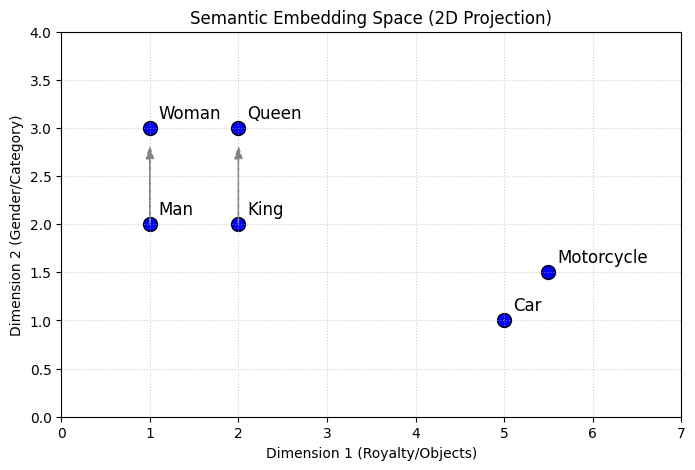

In [2]:
def plot_semantic_intuition():
    """Gera gráfico 2D ilustrando a intuição geométrica de um embedding semântico."""
    # Coordenadas simuladas de um espaço de embedding 2D
    words = ['Man', 'Woman', 'King', 'Queen', 'Car', 'Motorcycle']
    coords = np.array([
        [1.0, 2.0],   # Man
        [1.0, 3.0],   # Woman
        [2.0, 2.0],   # King
        [2.0, 3.0],   # Queen
        [5.0, 1.0],   # Car
        [5.5, 1.5]    # Motorcycle
    ])

    plt.figure(figsize=(8, 5))
    plt.scatter(coords[:, 0], coords[:, 1], c='blue', edgecolors='k', s=100)

    for i, word in enumerate(words):
        plt.annotate(word, (coords[i, 0] + 0.1, coords[i, 1] + 0.1), fontsize=12)

    # Desenhando setas de relação (Gender relation)
    plt.arrow(coords[0, 0], coords[0, 1], 0, 0.8, head_width=0.08, color='gray', linestyle='--', length_includes_head=True)
    plt.arrow(coords[2, 0], coords[2, 1], 0, 0.8, head_width=0.08, color='gray', linestyle='--', length_includes_head=True)

    plt.title('Semantic Embedding Space (2D Projection)')
    plt.xlabel('Dimension 1 (Royalty/Objects)')
    plt.ylabel('Dimension 2 (Gender/Category)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(0, 7)
    plt.ylim(0, 4)
    plt.show()

plot_semantic_intuition()

## 3. Teoria formal
Esta seção formaliza matematicamente os algoritmos clássicos de extração de características e de aprendizado de representações neurais, fornecendo embasamento para suas implementações práticas.

O aprendizado de representações visa mapear o sentido de uma informação de um domínio discreto $\mathcal{D}$ para um espaço vetorial contínuo $\mathbb{R}^d$. Esta tradução varia significativamente entre técnicas estatísticas com alto viés definido pelo programador, e abordagens baseadas em Deep Learning com baixo viés estatístico.

**TF-IDF (Term Frequency-Inverse Document Frequency)**
Uma das abordagens estatísticas mais conhecidas, o TF-IDF busca mitigar o problema de contabilizar palavras extremamente frequentes (como preposições) que não carregam alto valor semântico contextual. O cálculo é composto por duas partes:
1. Frequência do Termo (TF): Penaliza ou bonifica baseando-se na ocorrência interna.
$$TF(w, d) = \frac{\text{ocorrências de } w \text{ em } d}{\text{número total de palavras em } d}$$
2. Frequência Inversa do Documento (IDF): Penaliza palavras que aparecem em quase todos os documentos.
$$IDF(w, D) = \ln \left( \frac{\text{Total de documentos } (N)}{\text{número de documentos contendo } w} \right)$$
O embedding (vetor) de um documento utilizando TF-IDF é formado pelo produto para todo o vocabulário:
$$TFIDF(w, d, D) = TF(w, d) \times IDF(w, D)$$
*Hipótese de TF-IDF:* A ordem e a semântica densa das palavras são descartadas; o texto é tratado estritamente como bag-of-words.

**Autoencoders (Aprendizado não-supervisionado)**
Um Autoencoder é uma rede neural projetada para comprimir o espaço de entrada $\mathbf{x} \in \mathbb{R}^n$ para um espaço latente inferior (embedding) $\mathbf{z} \in \mathbb{R}^d$ ($d \ll n$) e, em seguida, reconstruir a entrada original.
A transformação é governada por uma função codificadora (Encoder) $E$ e uma decodificadora (Decoder) $D$:
$$\mathbf{z} = E(\mathbf{x}; \theta_E)$$
$$\mathbf{\hat{x}} = D(\mathbf{z}; \theta_D)$$
A otimização minimiza uma métrica de divergência, frequentemente o Erro Quadrático Médio (MSE), que atua como a loss de reconstrução:
$$\mathcal{L}_{AE}(\theta_E, \theta_D) = \frac{1}{N} \sum_{i=1}^{N} \|\mathbf{x}_i - D(E(\mathbf{x}_i))\|^2$$
A limitação fundamental é que a rede deve impor um gargalo de informação válido (tamanho reduzido no espaço latente) para forçar o aprendizado de características significativas, evitando que o modelo apenas replique a identidade.

## 4. Algoritmos
Esta seção desdobra o procedimento lógico para treinamento de um Autoencoder em passos claros e replicáveis computacionalmente, servindo como ponte entre a matemática e a sintaxe da linguagem Python.

```text
Algoritmo: Treinamento de um Autoencoder para Aprendizado de Embeddings
Entrada: Conjunto de dados X (dimensão n), tamanho do espaço latente d, taxa de aprendizado η, épocas E.
Saída: Rede Neural E (Encoder) treinada.

1. Inicializar os parâmetros da rede E (codificador) e D (decodificador) aleatoriamente.
2. PARA cada época de 1 até E FAÇA:
3.     PARA cada lote de amostras x contido em X FAÇA:
4.         z <- E(x)               // Reduz o espaço dimensional (obtenção do embedding)
5.         x_hat <- D(z)           // Tenta reconstruir a entrada original
6.         Loss <- MSE(x, x_hat)   // Calcula o erro quadrático entre entrada original e reconstrução
7.         Gradients <- Backward(Loss) // Propaga o erro usando backpropagation
8.         Atualizar parâmetros de E e D usando os Gradientes e η
9. FIM PARA
10. RETORNAR função E
```
Cada passagem pelo algoritmo força o espaço do gargalo central (z) a consolidar as dependências e padrões vitais dos dados, de tal forma que a rede D ainda obtenha insumo suficiente para recriar o arquivo original.

## 5. Implementação from scratch
Esta seção constrói o algoritmo estatístico TF-IDF estritamente a partir do NumPy, expondo a arquitetura algorítmica oculta pelos frameworks tradicionais de NLP.

A classe abaixo simula a lógica primária do TfidfVectorizer disponível na biblioteca scikit-learn.

In [3]:
class TFIDFFromScratch:
    """Implementa cálculo e vetorização TF-IDF a partir do zero usando apenas Numpy e listas."""

    def __init__(self):
        self.vocab = {}
        self.idf = {}

    def fit(self, documents):
        """
        Constrói o vocabulário e computa as frequências inversas dos documentos (IDF).
        documents: lista de listas contendo palavras em letras minúsculas.
        """
        N = len(documents)
        doc_counts = {}

        # Passo 1: Construção de vocabulário e contagem por documentos únicos
        for doc in documents:
            unique_words = set(doc)
            for word in unique_words:
                if word not in self.vocab:
                    self.vocab[word] = len(self.vocab)
                doc_counts[word] = doc_counts.get(word, 0) + 1

        # Passo 2: Calcular o IDF para cada palavra
        for word, count in doc_counts.items():
            # A fórmula exata implementada no paper original pode variar ligeiramente
            self.idf[word] = np.log(N / float(count))

    def transform(self, documents):
        """
        Aplica o mapeamento matemático de TF * IDF.
        Retorna matriz np.array de embeddings (Documentos x Tamanho do Vocab).
        """
        embeddings = np.zeros((len(documents), len(self.vocab)))

        for i, doc in enumerate(documents):
            total_words = len(doc)
            word_counts = {}
            for word in doc:
                word_counts[word] = word_counts.get(word, 0) + 1

            for word, count in word_counts.items():
                if word in self.vocab:
                    tf = count / float(total_words)
                    idx = self.vocab[word]
                    embeddings[i, idx] = tf * self.idf[word]

        return embeddings

# --- Teste Unitário (Célula de Assert) ---
def test_tfidf_implementation():
    docs = [
        ['jupiter', 'is', 'the', 'largest', 'planet'],
        ['mars', 'is', 'the', 'fourth', 'planet', 'from', 'the', 'sun']
    ]

    model = TFIDFFromScratch()
    model.fit(docs)
    vectors = model.transform(docs)

    # Validação do formato
    assert vectors.shape[0] == 2, 'A dimensão do vetor deve ser igual ao total de documentos.'
    assert vectors.shape[1] == len(model.vocab), 'A dimensão dos features falhou.'

    # Comparação conceitual do funcionamento (palavra isolada no primeiro documento)
    idx_jupiter = model.vocab['jupiter']
    idx_is = model.vocab['is']

    assert vectors[0, idx_jupiter] > 0.0, 'O TF-IDF de jupiter no doc 0 deve ser maior que zero.'
    assert vectors[0, idx_is] == 0.0, 'O IDF de is deveria anular a métrica (aparece em todos os docs).'
    print('TF-IDF Implementation From Scratch passou com sucesso!')

test_tfidf_implementation()

TF-IDF Implementation From Scratch passou com sucesso!


## 6. Implementação em PyTorch
Esta seção recria uma rede de Autoencoders em PyTorch puro, revelando como a retropropagação cria embeddings contínuos através de um funil de dimensionalidade estrito.

Neste componente prático, um dataset de alta dimensionalidade (vetores de 50 posições) passa por um funil até aterrissar em um plano de 2 dimensões.

In [4]:
class Autoencoder(nn.Module):
    """
    Arquitetura de rede neural que reduz uma entrada ao espaço de embedding (latente)
    e tenta reconstruir a entrada original.
    """
    def __init__(self, input_dim, hidden_dim, embedding_dim):
        super(Autoencoder, self).__init__()
        # Encoder E(x)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embedding_dim)
        )
        # Decoder D(z)
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        """Passagem forward completa retorna reconstrução e o embedding central."""
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

def train_autoencoder(model, dataloader, epochs=50, lr=0.01):
    """Loop de otimização em PyTorch sem abstrações."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    for _ in range(epochs):
        epoch_loss = 0.0
        for batch_x in dataloader:
            optimizer.zero_grad()

            x_hat, _ = model(batch_x)
            loss = criterion(x_hat, batch_x)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        losses.append(epoch_loss / len(dataloader))
    return losses

## 7. Experimentos e análise
Esta seção conduz múltiplos experimentos visuais de extração de contexto através de Autoencoders, documentando o impacto direto do tamanho do vetor do embedding nas métricas de reconstrução.

O experimento simula a projeção de 3 agrupamentos distintos. O modelo treina variações de hiperparâmetros (espaço de embedding de tamanho 2 contra tamanho 10).

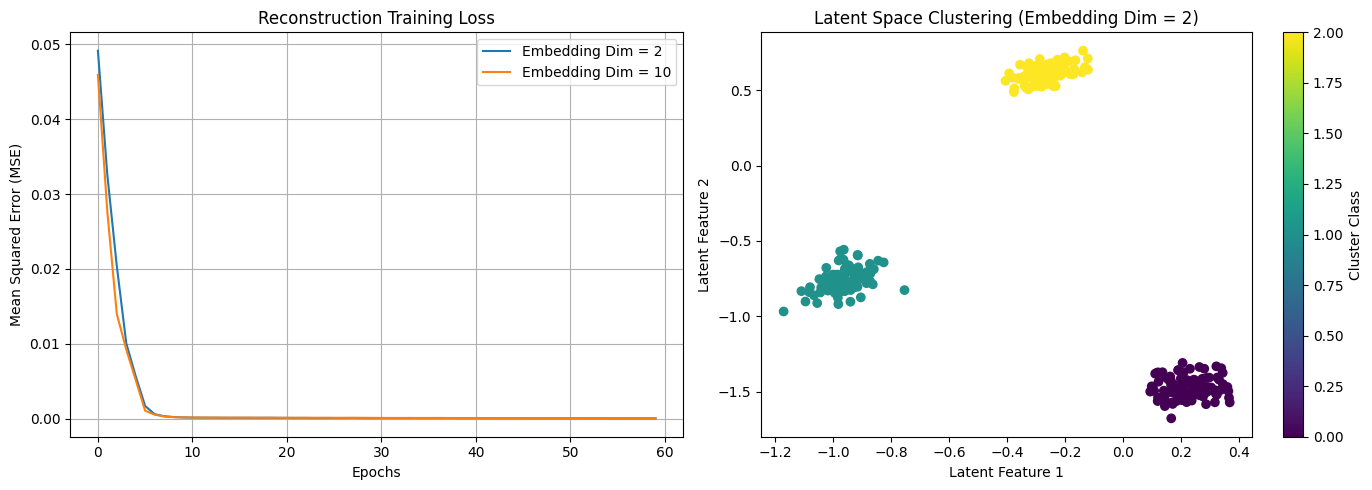

In [5]:
# Geração de dados de agrupamento sintético
def generate_synthetic_data(n_samples=300):
    centers = [[-1, 1], [-1, -1], [1, -1]]
    X = []
    y = []
    for i, c in enumerate(centers):
        # Gera dados bidimensionais com ruído, mas alocaremos em 50 dimensões fictícias
        cluster_data = np.random.randn(n_samples // 3, 2) * 0.1 + c
        high_dim_data = np.zeros((n_samples // 3, 50))
        high_dim_data[:, :2] = cluster_data
        X.append(high_dim_data)
        y.extend([i] * (n_samples // 3))
    return torch.tensor(np.vstack(X), dtype=torch.float32), np.array(y)

X_data, y_labels = generate_synthetic_data()
dataloader = torch.utils.data.DataLoader(X_data, batch_size=32, shuffle=True)

# Experimento 1: Gargalo forte (Dimensão = 2)
model_2d = Autoencoder(input_dim=50, hidden_dim=16, embedding_dim=2)
loss_2d = train_autoencoder(model_2d, dataloader, epochs=60)

# Experimento 2: Gargalo moderado (Dimensão = 10)
model_10d = Autoencoder(input_dim=50, hidden_dim=16, embedding_dim=10)
loss_10d = train_autoencoder(model_10d, dataloader, epochs=60)

# Análise Visual: Curvas de Loss e Projeção Latente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MSE Loss Comparativo
ax1.plot(loss_2d, label='Embedding Dim = 2')
ax1.plot(loss_10d, label='Embedding Dim = 10')
ax1.set_title('Reconstruction Training Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Mean Squared Error (MSE)')
ax1.legend()
ax1.grid(True)

# Plot 2: Espaço Latente (apenas aplicável em modelo com 2 dimensões)
_, embeddings_2d = model_2d(X_data)
embeddings_np = embeddings_2d.detach().numpy()
scatter = ax2.scatter(embeddings_np[:, 0], embeddings_np[:, 1], c=y_labels, cmap='viridis')
ax2.set_title('Latent Space Clustering (Embedding Dim = 2)')
ax2.set_xlabel('Latent Feature 1')
ax2.set_ylabel('Latent Feature 2')
plt.colorbar(scatter, ax=ax2, label='Cluster Class')
plt.tight_layout()
plt.show()

**Interpretação e Diagnósticos:**
O erro de reconstrução no Experimento 2 (Dim=10) converge mais rapidamente para a margem de erro inferior, o que não surpreende: dimensões maiores retêm maior capacidade paramétrica da entrada e afrouxam o estrangulamento da compressão de informação. No entanto, a compressão do Experimento 1 (Dim=2) reflete a real capacidade de agrupamento do embedding; observe que a projeção 2D mapeia organicamente a entrada nos três grandes clusters estipulados originalmente.
*O que pode dar errado:* Caso a função de compressão atue de maneira idêntica à saída para Dim=50, o Autoencoder transforma-se na função identidade e aprende a não generalizar, ou seja, falha em extrair o significado semântico e contextual. O diagnóstico disso reside no monitoramento de agrupamentos vazios ou com sobreposição uniforme total no espaço das representações gráficas.

## 8. Conexões com ML moderno
Esta seção estende a aplicabilidade do conteúdo matemático para frameworks e topologias avançadas (LLMs e RAG), atestando a extrema relevância global deste tópico em pesquisas modernas (2024-2025).

Os embeddings permanecem como o coração do processamento unificado da inteligência artificial contemporânea:
- **Retrieval-Augmented Generation (RAG):** Os sistemas RAG combinam a força gerativa dos LLMs com acurácia factual, buscando contextos e parágrafos precisos. Cerca de 99% da busca para RAG baseia-se em embeddings. O algoritmo converte a pergunta natural do usuário em um vetor dimensional, buscando, usando similaridade de cossenos, pedaços textuais mapeados em bancos de dados vetoriais locais.
- **Espaços Semânticos Multimodais:** Em modelos como o CLIP (usado em difusão de imagens), texto, áudio e imagem são espremidos num espaço de embedding interconectado. Se o usuário escreve a palavra passarinho ou imputa a foto real de uma ave, as redes os empurram para uma localização similar no hiperespaço.
- **Por que ainda importa em 2025?:** O treinamento eficiente e o cálculo da distância desses vetores formam o estrato essencial no roteamento e quantização de toda comunicação em modelos trilionários em parâmetros (como o LLaMA e DeepSeek).

**Papers Históricos Relevantes:**
- Mikolov, T., et al. (2013). Efficient Estimation of Word Representations in Vector Space. (Este artigo demonstrou de maneira inigualável arquiteturas contínuas, como CBOW e Skip-gram, para processamento linguístico).
- Hinton, G. E., & Salakhutdinov, R. R. (2006). Reducing the dimensionality of data with neural networks. (Comprovou que autoencoders treinados com restrições arquiteturais performam compressão de dados não lineares superiores a componentes principais isolados).

## 9. Exercícios
Esta seção exige a fixação do conteúdo abordado através do desenvolvimento de lógica algorítmica isolada e proposição de projetos reflexivos de aprendizado.

### Exercícios Resolvidos

**Exercício 1:** Considere os documentos `A = "machine learning is fun"` e `B = "machine learning is complex"`. Calcule logicamente (sem programar) quais termos terão um IDF zerado (0).
* **Solução Comentada:** O modelo IDF rebaixa palavras frequentes globalmente através da fórmula logarítmica. A palavra machine, a palavra learning, e a palavra is ocorrem em ambos os documentos ($N=2$, frequência = 2). Aplicando $\ln(2/2) = \ln(1) = 0$. Portanto, o algoritmo penaliza-as a zero para dar vazão máxima às palavras semânticas fun e complex.

**Exercício 2:** Em Python, como você calcularia o alinhamento contextual entre a vetorização de dois conceitos dentro de um espaço utilizando cosseno? Implemente.
* **Solução Comentada:** O ângulo define se dois pontos apontam para o mesmo vetor dimensional. O scikit-learn dispõe de métricas adequadas:
```python
# Embedding vetorial fictício
embedding_carro = np.array([[0.8, -0.2, 0.1]])
embedding_moto = np.array([[0.7, -0.1, 0.2]])

similarity = cosine_similarity(embedding_carro, embedding_moto)
print(f"Cosseno direcional: {similarity[0, 0]:.4f}")
# Resultado perto de 1 indica altíssima correlação de sentido.
```

**Exercício 3:** Relacione a utilidade das duas ramificações clássicas de treinamento do Word2Vec propostas no artigo original de Mikolov.
* **Solução Comentada:** A primeira ramificação, o Continuous Bag of Words (CBOW), recebe o contexto ao redor para adivinhar a palavra do meio. O reverso lógico é o Skip-gram, que recebe a palavra-foco, projeta para o espaço de embedding latente, e tem como base inferir e construir as palavras imediatamente adjacentes a ela (posteriores e anteriores).

### Desafios Abertos

**Desafio 1 (Implementação Prática): Representação Contínua de E-commerce**
Construa uma classe Python que consolida embeddings heterogêneos. Extraia de um dado textual a Categoria, a Subcategoria, e a Marca (podendo utilizar intervenções externas ou regras) de um Produto fictício. A partir dos vetores de categorias isoladas, forme uma matriz conjunta capaz de classificar proximidades. Dica: A estrutura lógica visa comparar um tênis de categoria A com maquiagens de categoria A cruzando os vetores mesclados.

**Desafio 2 (Teórico/Reflexivo): Corpus Generalista vs Corpus Local em Arquitetura de Saúde**
Você utiliza um embedding global da OpenAI (treinado com toda a Internet pública) para avaliar correlações entre nomes de substâncias farmacêuticas e quadros de diagnóstico cirúrgico do seu hospital. No entanto, você nota que a distância entre medicamentos é baixíssima para qualquer entrada. Projete a explicação do evento fundamentada em Viés de Corpus, e descreva detalhadamente quais passos práticos de rotina você utilizaria na construção de um modelo com Corpus Local específico que diferenciasse adequadamente os medicamentos com viés de dados corporativos.